In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data(path="mnist.npz")
print(f"Training dataset shape: {x_train.shape}")
print(f"Test dataset shape: {x_test.shape}")

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

Training dataset shape: (60000, 28, 28)
Test dataset shape: (10000, 28, 28)


In [139]:
(x_train[3].dtype)

dtype('float32')

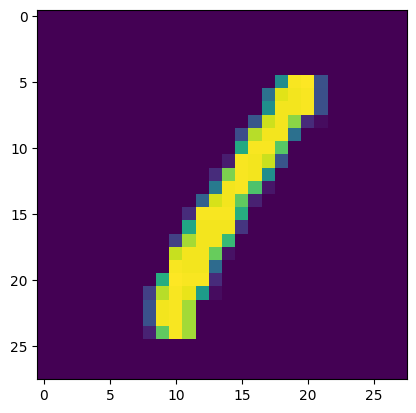

In [140]:
plt.imshow(x_train[3])


In [141]:
for i in range(len(x_train)): x_train[i] = x_train[i] / 255.0
for i in range(len(x_test)): x_test[i] = x_test[i] / 255.0

x_train[123].max()

np.float32(1.0)

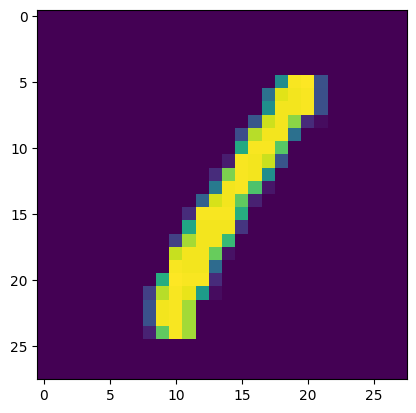

In [142]:
plt.imshow(x_train[3]) 

In [143]:
print(np.unique(x_train[3]))

[0.         0.03137255 0.04705882 0.05882353 0.07843138 0.09019608
 0.09411765 0.12156863 0.1254902  0.15294118 0.1882353  0.23529412
 0.24313726 0.24705882 0.2509804  0.25882354 0.26666668 0.3137255
 0.34901962 0.36862746 0.3764706  0.40784314 0.4862745  0.49411765
 0.49803922 0.54901963 0.5921569  0.60784316 0.62352943 0.6745098
 0.72156864 0.7411765  0.75686276 0.76862746 0.8039216  0.827451
 0.8627451  0.8666667  0.89411765 0.91764706 0.92156863 0.9254902
 0.9411765  0.95686275 0.96862745 0.9843137  0.99215686 1.        ]


In [144]:
model0 = tf.keras.models.Sequential()

model0.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model0.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model0.add(tf.keras.layers.Dense(10, activation='softmax'))

model0.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
nepochs = 3
model0.fit(x_train, y_train, epochs=nepochs)

Epoch 1/3


/Users/francescospecchia/Desktop/UNI/DL/Repo/Lab/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 513us/step - accuracy: 0.8576 - loss: 0.5043
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 434us/step - accuracy: 0.9147 - loss: 0.3018
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 408us/step - accuracy: 0.9220 - loss: 0.2778


In [145]:
test_loss, test_acc = model0.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.9232 - loss: 0.2742
Test Loss: 0.27418577671051025
Test Accuracy: 0.9232000112533569


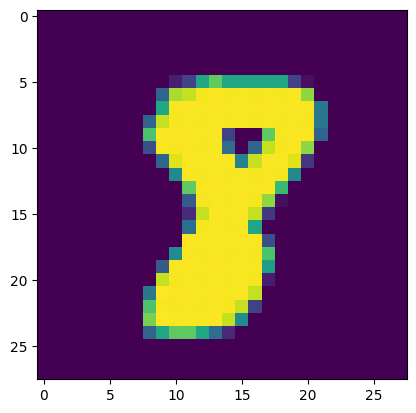

In [146]:
randomint = np.random.randint(0, len(x_test))
rnd_img = x_test[randomint]
plt.imshow(rnd_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicted label:  8
Ground Truth:  8
Class probabilities: [1.7695392e-06 2.5941351e-06 1.3633796e-04 1.1596570e-03 9.6914995e-08
 3.2397872e-03 8.8500713e-07 1.4974529e-05 9.9478525e-01 6.5868016e-04]


<BarContainer object of 10 artists>

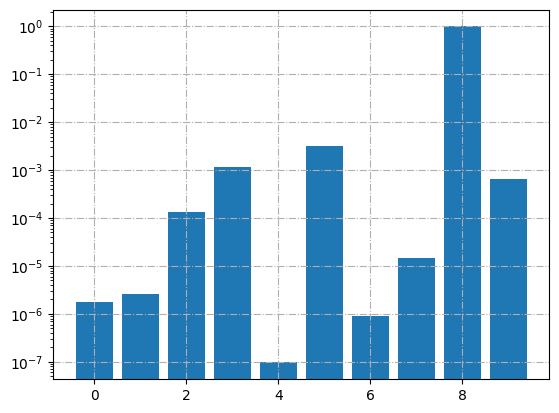

In [147]:
preds = model0.predict(rnd_img[None, ...])
predicted_label = np.argmax(preds, axis=1)[0]
print("Predicted label: ", predicted_label)
print("Ground Truth: ", y_test[randomint])
print("Class probabilities:", preds[0])

classes = [i for i in range(0, 10)]
plt.semilogy()
plt.grid('both', linestyle='-.')
plt.bar(classes, (preds[0]))

In [148]:
import optuna as op

# Returns the loss and accuracy of a keras model under specific hyperparameters
def model_op(hyperparameters: dict, x_train, y_train, x_test, y_test):
    model = tf.keras.models.Sequential()

    # Input layer
    model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

    # Add n layers where n is the number of units passed from the hyperparameters dict
    
    model.add(tf.keras.layers.Dense(units=hyperparameters['units'], activation='leaky_relu'))

    # Output layer with softmax
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hyperparameters['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    model.fit(x_train, y_train, epochs=hyperparameters['epochs'], verbose=0) # dont show training data
    loss, acc = model.evaluate(x_test, y_test)

    return loss, acc


study = op.study.create_study()


def objective(trial: op.Trial):
    lr = trial.suggest_float('learning_rate', 1e-4, 1)
    uns = trial.suggest_int('units', 1, 300)
    epoch = trial.suggest_int('epochs', 1, 15)

    hyp = {'learning_rate': lr, 'units': uns, 'epochs': epoch}
    loss, acc = model_op(hyp, x_train, y_train, x_test, y_test) #global i dont care
    trial.set_user_attr('accuracy', acc)

    return loss


study.optimize(objective, n_trials=70)

[I 2026-04-17 13:33:05,769] A new study created in memory with name: no-name-654c8f2f-2d66-4a0b-8c46-d535c02d5cdb


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - accuracy: 0.9166 - loss: 2.4792


[I 2026-04-17 13:33:12,782] Trial 0 finished with value: 2.47924542427063 and parameters: {'learning_rate': 0.02777926765022619, 'units': 114, 'epochs': 4}. Best is trial 0 with value: 2.47924542427063.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.9445 - loss: 585.0215


[I 2026-04-17 13:33:27,363] Trial 1 finished with value: 585.0215454101562 and parameters: {'learning_rate': 0.46737513098012834, 'units': 113, 'epochs': 8}. Best is trial 0 with value: 2.47924542427063.


...

[I 2026-04-17 13:50:35,972] Trial 67 finished with value: 44.08623504638672 and parameters: {'learning_rate': 0.11838293329114763, 'units': 131, 'epochs': 7}. Best is trial 65 with value: 0.07335396856069565.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - accuracy: 0.9320 - loss: 16.4302


[I 2026-04-17 13:50:57,505] Trial 68 finished with value: 16.430185317993164 and parameters: {'learning_rate': 0.04129608011387698, 'units': 280, 'epochs': 8}. Best is trial 65 with value: 0.07335396856069565.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.9324 - loss: 7.1877


[I 2026-04-17 13:51:04,006] Trial 69 finished with value: 7.1877217292785645 and parameters: {'learning_rate': 0.08050925617756617, 'units': 46, 'epochs': 6}. Best is trial 65 with value: 0.07335396856069565.


In [149]:
params = study.trials_dataframe()

params

,number,value,datetime_start,datetime_complete,duration,params_epochs,params_learning_rate,params_units,user_attrs_accuracy,state
0,0,2.479245,2026-04-17 13:33:05.776797,2026-04-17 13:33:12.782696,0 days 00:00:07.005899,4,0.027779,114,0.9166,COMPLETE
1,1,585.021545,2026-04-17 13:33:12.783120,2026-04-17 13:33:27.363334,0 days 00:00:14.580214,8,0.467375,113,0.9445,COMPLETE
2,2,1811.266357,2026-04-17 13:33:27.363645,2026-04-17 13:33:49.676063,0 days 00:00:22.312418,15,0.780660,83,0.9445,COMPLETE
3,3,1870.922974,2026-04-17 13:33:49.676443,2026-04-17 13:34:09.051579,0 days 00:00:19.375136,10,0.745657,117,0.9502,COMPLETE
4,4,313.660065,2026-04-17 13:34:09.052040,2026-04-17 13:34:18.422520,0 days 00:00:09.370480,11,0.898792,21,0.8903,COMPLETE
...,...,...,...,...,...,...,...,...,...,...
65,65,0.073354,2026-04-17 13:49:56.578776,2026-04-17 13:50:16.181690,0 days 00:00:19.602914,7,0.000533,278,0.9771,COMPLETE
66,66,13.070150,2026-04-17 13:50:16.182070,2026-04-17 13:50:22.460782,0 days 00:00:06.278712,7,0.176946,22,0.9076,COMPLETE
67,67,44.086235,2026-04-17 13:50:22.461144,2026-04-17 13:50:35.972345,0 days 00:00:13.511201,7,0.118383,131,0.9451,COMPLETE
68,68,16.430185,2026-04-17 13:50:35.972984,2026-04-17 13:50:57.505732,0 days 00:00:21.532748,8,0.041296,280,0.9320,COMPLETE


In [150]:
best_par = study.best_params
best_trl = study.best_trial
print(f'Best set of hyperparameters: {best_par}')
print(f'At trial #{best_trl.number}')
print(f'With accuracy: {best_trl.user_attrs['accuracy']}')

Best set of hyperparameters: {'learning_rate': 0.000533397595949892, 'units': 278, 'epochs': 7}
At trial #65
With accuracy: 0.9771000146865845


Text(0.5, 1.0, 'Loss and accuracy during the search of hyperparameters')

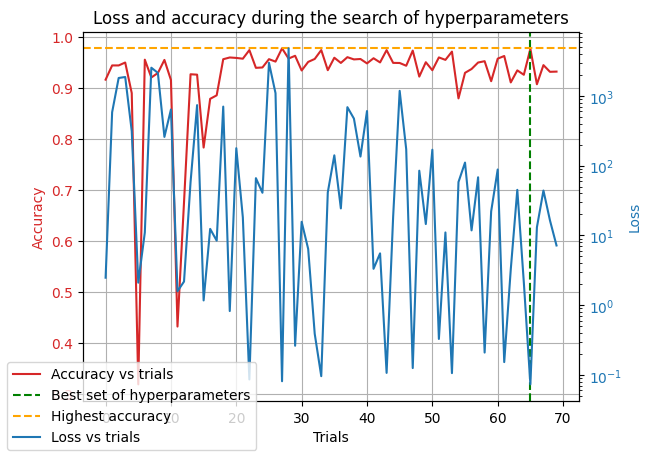

In [154]:

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Trials')
ax1.set_ylabel('Accuracy', color=color)
ax1.plot(params['number'], params['user_attrs_accuracy'], color=color, label='Accuracy vs trials')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Loss', color=color)  # we already handled the x-label with ax1
ax2.plot(params['number'], params['value'], color=color, label='Loss vs trials')
ax2.tick_params(axis='y', labelcolor=color)
ax2.semilogy()

ax1.grid('both')

ax1.axvline(best_trl.number, c ='green', linestyle = '--', label='Best set of hyperparameters')
ax1.axhline(np.max(params['user_attrs_accuracy']), c ='orange', linestyle = '--', label='Highest accuracy')
fig.legend(loc='lower left')
plt.title('Loss and accuracy during the search of hyperparameters')